<a href="https://colab.research.google.com/github/Sneha-code01/ML/blob/main/batterypredict_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# current inida = 0.71, renewable = 0.05, 2035 = 0.35 _CAE
# manufacture = 65kwh electricity required and used 20 for 100%recycle credit
import pandas as pd
from itertools import product

chemistries = [
    'LFP','LTO','LMO','LCO','NCA',
    'NMC111','NMC532','NMC622',
    'NMC811','NMC442','NMC95'
]

scenarios = [
    'Current_India_Grid',
    'Renewable_India',
    'India_2035'
]

recycling_rates = [0,20,30,40,50,60,70,80,90,100]

energy_density = {
    'LFP':140,
    'LTO':80,
    'LMO':150,
    'LCO':190,
    'NCA':260,
    'NMC111':230,
    'NMC532':220,
    'NMC622':250,
    'NMC811':280,
    'NMC442':210,
    'NMC95':300
}

material_emission = {
    'LFP':30,
    'LTO':33,
    'LMO':34,
    'LCO':48,
    'NCA':52,
    'NMC111':43,
    'NMC442':45,
    'NMC532':47,
    'NMC622':50,
    'NMC811':54,
    'NMC95':56
}

cell_production = {
    'LFP':13,
    'LTO':14,
    'LMO':14,
    'LCO':15,
    'NCA':17,
    'NMC111':15,
    'NMC442':15,
    'NMC532':16,
    'NMC622':17,
    'NMC811':18,
    'NMC95':19
}

grid_factor = {
    'Current_India_Grid':0.71,
    'Renewable_India':0.05,
    'India_2035':0.35
}

data = list(product(
    chemistries,
    scenarios,
    recycling_rates
))

df = pd.DataFrame(
    data,
    columns=[
        'Chemistry',
        'Scenario',
        'Recycling_Rate'
    ]
)

df['Energy_Density_kWh'] = (
    df['Chemistry']
    .map(energy_density)
)

df['Material_Emission'] = (
    df['Chemistry']
    .map(material_emission)
)

df['Cell_Production_Emission'] = (
    df['Chemistry']
    .map(cell_production)
)

df['Base_Emission'] = (
    df['Material_Emission']
    +
    df['Cell_Production_Emission']
)

df['Grid_Factor'] = (
    df['Scenario']
    .map(grid_factor)
)

# Manufacturing electricity demand
manufacturing_energy = 65

df['Manufacturing_Emission'] = (
    manufacturing_energy
    *
    df['Grid_Factor']
)

# Recycling credit
df['Recycling_Credit'] = (
    20
    *
    df['Recycling_Rate']
    /100
)
#unit co2-eq-gwp100
# Final target column
df['CO2-eq'] = (
    df['Base_Emission']
    +
    df['Manufacturing_Emission']
    -
    df['Recycling_Credit']
)

print(df[['Chemistry','Scenario','Recycling_Rate','Energy_Density_kWh','CO2-eq']])

df.to_csv(
    'battery_dataset.csv',
    index=False
)
#Research_papers: Ellingsen et al. (2014) paper,Ciez & Whitacre (2019) paper,Harper et al. (2019) review paper



    Chemistry            Scenario  Recycling_Rate  Energy_Density_kWh  CO2-eq
0         LFP  Current_India_Grid               0                 140   89.15
1         LFP  Current_India_Grid              20                 140   85.15
2         LFP  Current_India_Grid              30                 140   83.15
3         LFP  Current_India_Grid              40                 140   81.15
4         LFP  Current_India_Grid              50                 140   79.15
..        ...                 ...             ...                 ...     ...
325     NMC95          India_2035              60                 300   85.75
326     NMC95          India_2035              70                 300   83.75
327     NMC95          India_2035              80                 300   81.75
328     NMC95          India_2035              90                 300   79.75
329     NMC95          India_2035             100                 300   77.75

[330 rows x 5 columns]


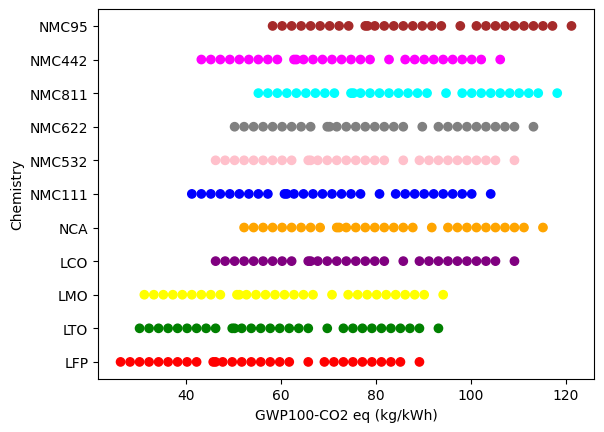

In [4]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}

plt.scatter(
    df['CO2-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('GWP100-CO2 eq (kg/kWh)')
plt.ylabel('Chemistry')
plt.show()

In [26]:
# Acidification factors for electricity scenarios
#unit is kg_so2_eq
acid_grid_factor = {
    'Current_India_Grid':0.0045,
    'India_2035':0.0020,
    'Renewable_India':0.0005
}

# Base acidification values (kg SO2-eq/kWh battery)
base_acidification = {
    'LFP':0.16,
    'LTO':0.18,
    'LMO':0.25,
    'LCO':0.42,
    'NCA':0.48,
    'NMC111':0.28,
    'NMC442':0.31,
    'NMC532':0.34,
    'NMC622':0.40,
    'NMC811':0.46,
    'NMC95':0.50
}
# Chemistry-specific recycling credits for acidification
acid_recycling_credit = {
    'LFP': 0.04,
    'LTO': 0.04,
    'LMO': 0.05,
    'LCO': 0.10,
    'NCA': 0.12,
    'NMC111': 0.08,
    'NMC442': 0.09,
    'NMC532': 0.10,
    'NMC622': 0.11,
    'NMC811': 0.13,
    'NMC95': 0.14
}
# Adding base acidification column
df['Base_Acidification'] = df['Chemistry'].map(base_acidification)

df['Acid_Grid_Factor'] = df['Scenario'].map(acid_grid_factor)

manufacturing_energy = 65

df['Manufacturing_Acidification'] = (
    manufacturing_energy * df['Acid_Grid_Factor']
)

df['Acidification_Credit'] = (
    df['Chemistry'].map(acid_recycling_credit)
    * df['Recycling_Rate']
    / 100
)

df['Acidification-eq'] = (
    df['Base_Acidification']
    + df['Manufacturing_Acidification']
    - df['Acidification_Credit']
)
print(
    df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq',
        'Energy_Density_kWh',
        'Acidification-eq']]
)

    Chemistry            Scenario  Recycling_Rate  CO2-eq  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0   89.15                 140   
1         LFP  Current_India_Grid              20   85.15                 140   
2         LFP  Current_India_Grid              30   83.15                 140   
3         LFP  Current_India_Grid              40   81.15                 140   
4         LFP  Current_India_Grid              50   79.15                 140   
..        ...                 ...             ...     ...                 ...   
325     NMC95          India_2035              60   85.75                 300   
326     NMC95          India_2035              70   83.75                 300   
327     NMC95          India_2035              80   81.75                 300   
328     NMC95          India_2035              90   79.75                 300   
329     NMC95          India_2035             100   77.75                 300   

     Acidification-eq  
0  

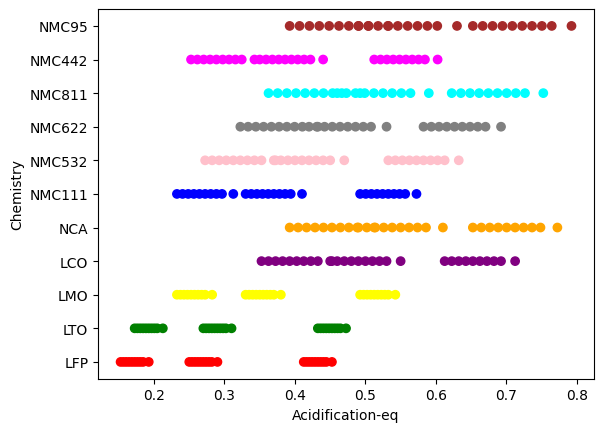

In [6]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}
plt.scatter(
    df['Acidification-eq'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Acidification-eq')
plt.ylabel('Chemistry')
plt.show()

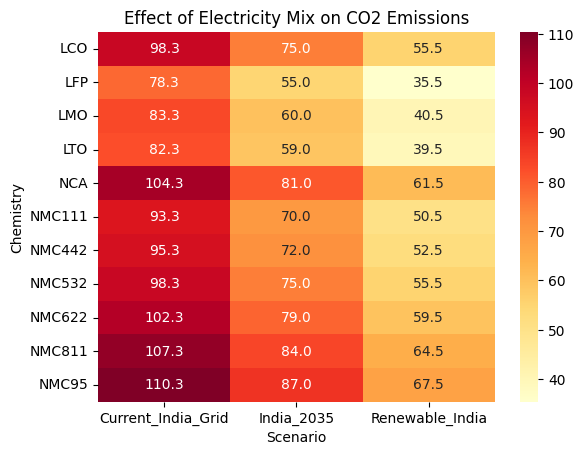

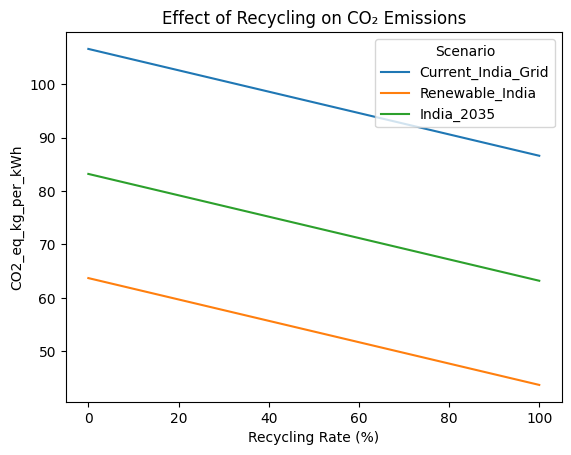

In [9]:
import seaborn as sns
pivot = df.pivot_table(
    values='CO2-eq',
    index='Chemistry',
    columns='Scenario',
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.1f'
)

plt.title('Effect of Electricity Mix on CO2 Emissions')
plt.show()
plt.figure()
sns.lineplot(
    data=df,
    x='Recycling_Rate',
    y='CO2-eq',
    hue='Scenario',
    errorbar=None
)

plt.xlabel('Recycling Rate (%)')
plt.ylabel('CO2_eq_kg_per_kWh')
plt.title('Effect of Recycling on CO₂ Emissions')
plt.show()


In [10]:
#Human Toxicity Potential (HTP) Nickel mining, Cobalt mining, Lithium production, Graphite processing
#taken from the research papers and greet it sthe value due to the material it self
base_htp = {
    'LFP':8,
    'LTO':9,
    'LMO':11,
    'LCO':28,
    'NCA':32,
    'NMC111':22,
    'NMC442':24,
    'NMC532':26,
    'NMC622':29,
    'NMC811':34,
    'NMC95':37
}
#kg 1,4-DCB-eq/kWh is unit of htp
#because electricity contributes much less to HTP than material extraction.(65*elec source htp contri)
htp_grid_factor = {
    'Current_India_Grid':0.035,
    'India_2035':0.020,
    'Renewable_India':0.008
}
#High Ni/Co chemistries gain more from recycling. ie the htp is very less in such cases
recycling_credit_htp = {
    'LFP':4,
    'LTO':4,
    'LMO':5,
    'LCO':12,
    'NCA':14,
    'NMC111':10,
    'NMC442':11,
    'NMC532':12,
    'NMC622':13,
    'NMC811':15,
    'NMC95':16
}
#htp column addition
df['Base_HTP'] = df['Chemistry'].map(base_htp)

df['HTP_Grid_Factor'] = df['Scenario'].map(htp_grid_factor)

df['Manufacturing_HTP'] = (
    65 * df['HTP_Grid_Factor']
)

df['HTP_Recycling_Credit'] = (
    df['Chemistry'].map(recycling_credit_htp)
    * df['Recycling_Rate']
    / 100
)

df['Human_Toxicity'] = (
    df['Base_HTP']
    + df['Manufacturing_HTP']
    - df['HTP_Recycling_Credit']
)
#papers by Majeau-Bettez, Ellingsen, and Ciez & Whitacre
print(df[['Chemistry',
        'Scenario',
        'Recycling_Rate',
        'CO2-eq',
        'Energy_Density_kWh',
        'Acidification-eq',
          'Human_Toxicity']])

    Chemistry            Scenario  Recycling_Rate  CO2-eq  Energy_Density_kWh  \
0         LFP  Current_India_Grid               0   89.15                 140   
1         LFP  Current_India_Grid              20   85.15                 140   
2         LFP  Current_India_Grid              30   83.15                 140   
3         LFP  Current_India_Grid              40   81.15                 140   
4         LFP  Current_India_Grid              50   79.15                 140   
..        ...                 ...             ...     ...                 ...   
325     NMC95          India_2035              60   85.75                 300   
326     NMC95          India_2035              70   83.75                 300   
327     NMC95          India_2035              80   81.75                 300   
328     NMC95          India_2035              90   79.75                 300   
329     NMC95          India_2035             100   77.75                 300   

     Acidification-eq  Huma

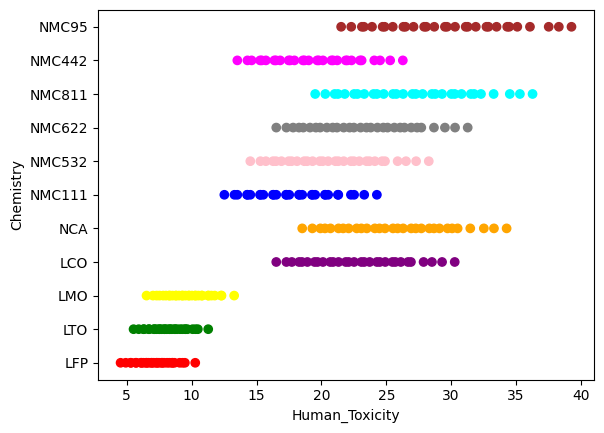

In [11]:
import matplotlib.pyplot as plt
color_map = {
    'LFP':'red',
    'LTO':'green',
    'LMO':'yellow',
    'LCO':'purple',
    'NCA':'orange',
    'NMC111':'blue',
    'NMC532':'pink',
    'NMC622':'grey',
    'NMC811':'cyan',
    'NMC442':'magenta',
    'NMC95':'brown'
}
plt.scatter(
    df['Human_Toxicity'],
    df['Chemistry'],
    c=df['Chemistry'].map(color_map)
)

plt.xlabel('Human_Toxicity')
plt.ylabel('Chemistry')
plt.show()

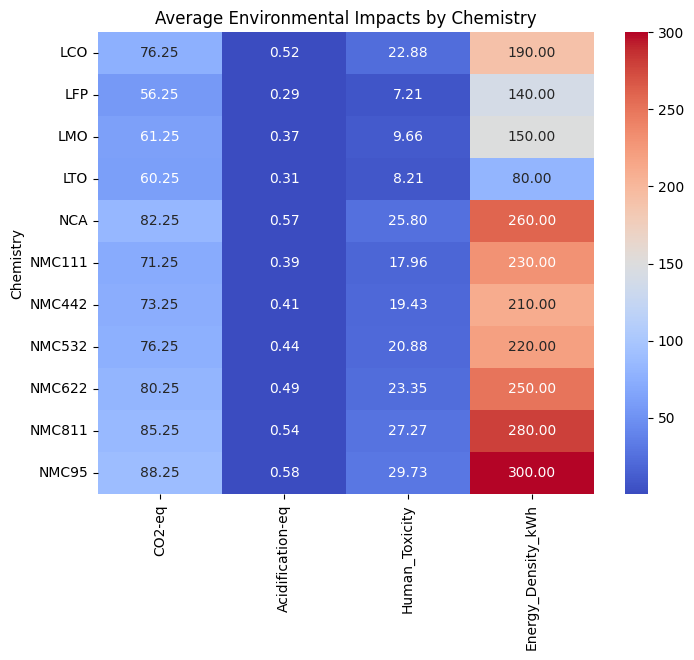

In [25]:
#plotting co2,acidification and htp graph together
import seaborn as sns
import matplotlib.pyplot as plt

avg_df = df.groupby('Chemistry')[
    [
        'CO2-eq',
        'Acidification-eq',
        'Human_Toxicity',
        'Energy_Density_kWh',
    ]
].mean()

plt.figure(figsize=(8,6))

sns.heatmap(
    avg_df,
    annot=True,
    cmap = 'coolwarm',
    fmt='.2f'
)

plt.title('Average Environmental Impacts by Chemistry')
plt.show()